In [26]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

In [27]:
CSV_PATH = Path("CC GENERAL.csv")

df = pd.read_csv(CSV_PATH)
display(df.head())
print(df.shape)
df.info()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


(8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  


In [28]:
df.drop(columns=["CUST_ID"], inplace=True)

In [29]:
df_features = df.columns.tolist()
df_features

['BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

In [30]:
df.isna().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [31]:
df.fillna(df.median(), inplace=True)
df.drop_duplicates(inplace=True)
df.shape

(8950, 17)

In [32]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [17]:
k = range(2, 14)
inertias = []
silhouettes = []

for i in k:
    k_means = KMeans(n_clusters=i, random_state=42, n_init=50)
    k_means.fit(df_scaled)
    inertias.append(k_means.inertia_)
    silhouettes.append(silhouette_score(df_scaled, k_means.labels_))

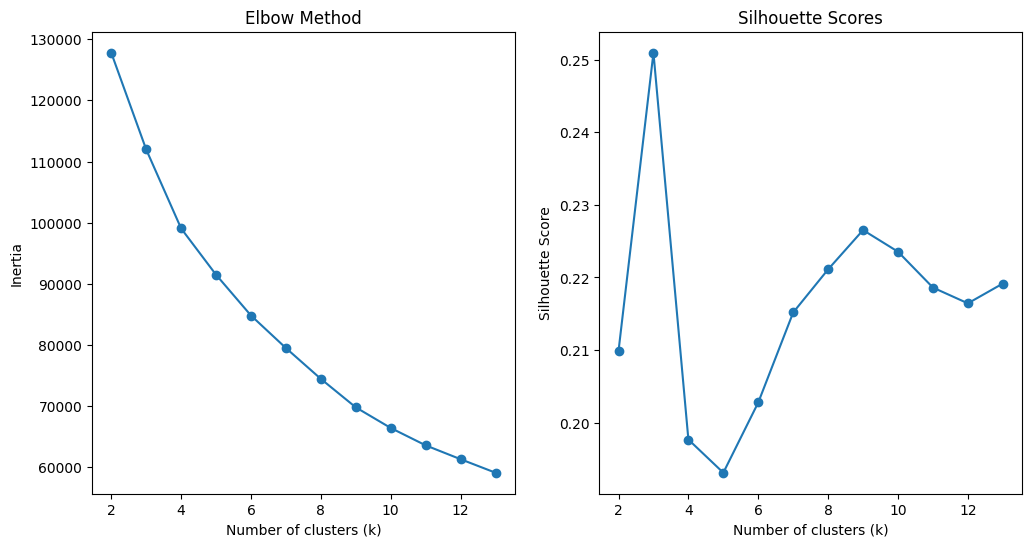

In [18]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(k, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k, silhouettes, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

plt.show()

In [47]:
k_test = 2
k_means = KMeans(n_clusters=k_test, random_state=42, n_init=50)
k_means.fit(df_scaled)

df["Segment"] = k_means.labels_

df["Segment"].value_counts()

Segment
1    5237
0    3713
Name: count, dtype: int64

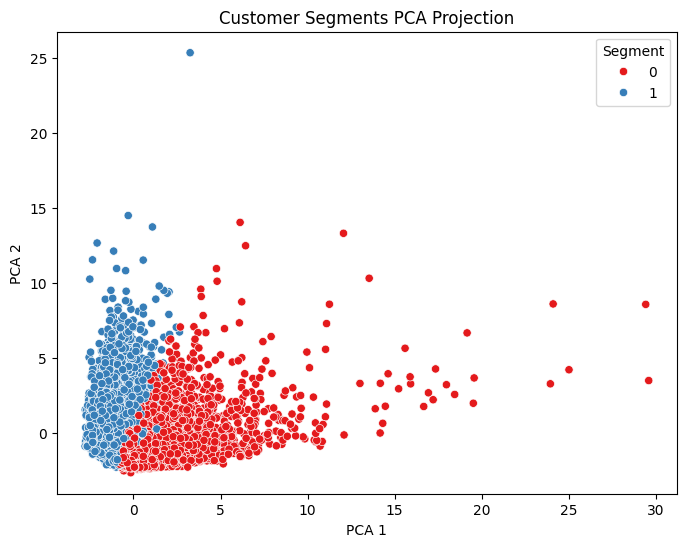

In [48]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df["Segment"], palette="Set1")
plt.title('Customer Segments PCA Projection')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Segment')
plt.show()

In [49]:
df.value_counts("Segment")

Segment
1    5237
0    3713
Name: count, dtype: int64

In [50]:
clusters_mean = df.groupby("Segment").mean()
clusters_mean

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Segment,,,,,,,,,,,,,,,,,
0,1380.746601,0.945701,2026.962731,1143.166889,884.125626,441.024974,0.905587,0.362526,0.731035,0.058551,1.417452,30.711285,5103.479734,2190.622510,864.863204,0.270636,11.678158
1,1694.736983,0.828754,277.366935,201.973613,75.672517,1360.200636,0.195950,0.088970,0.104522,0.189448,4.547260,3.364904,4062.365453,1408.794366,830.757779,0.070818,11.403284


In [51]:
clusters_median = df.groupby("Segment").median()
clusters_median

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Segment,,,,,,,,,,,,,,,,,
0,509.685823,1.0,1189.04,370.3,533.66,0.000000,1.000000,0.25,0.833333,0.0,0.0,20.0,4000.0,1222.419114,220.475303,0.083333,12.0
1,1068.985549,1.0,83.00,0.0,0.00,378.517888,0.083333,0.00,0.000000,0.1,2.0,1.0,3000.0,662.354973,354.529079,0.000000,12.0


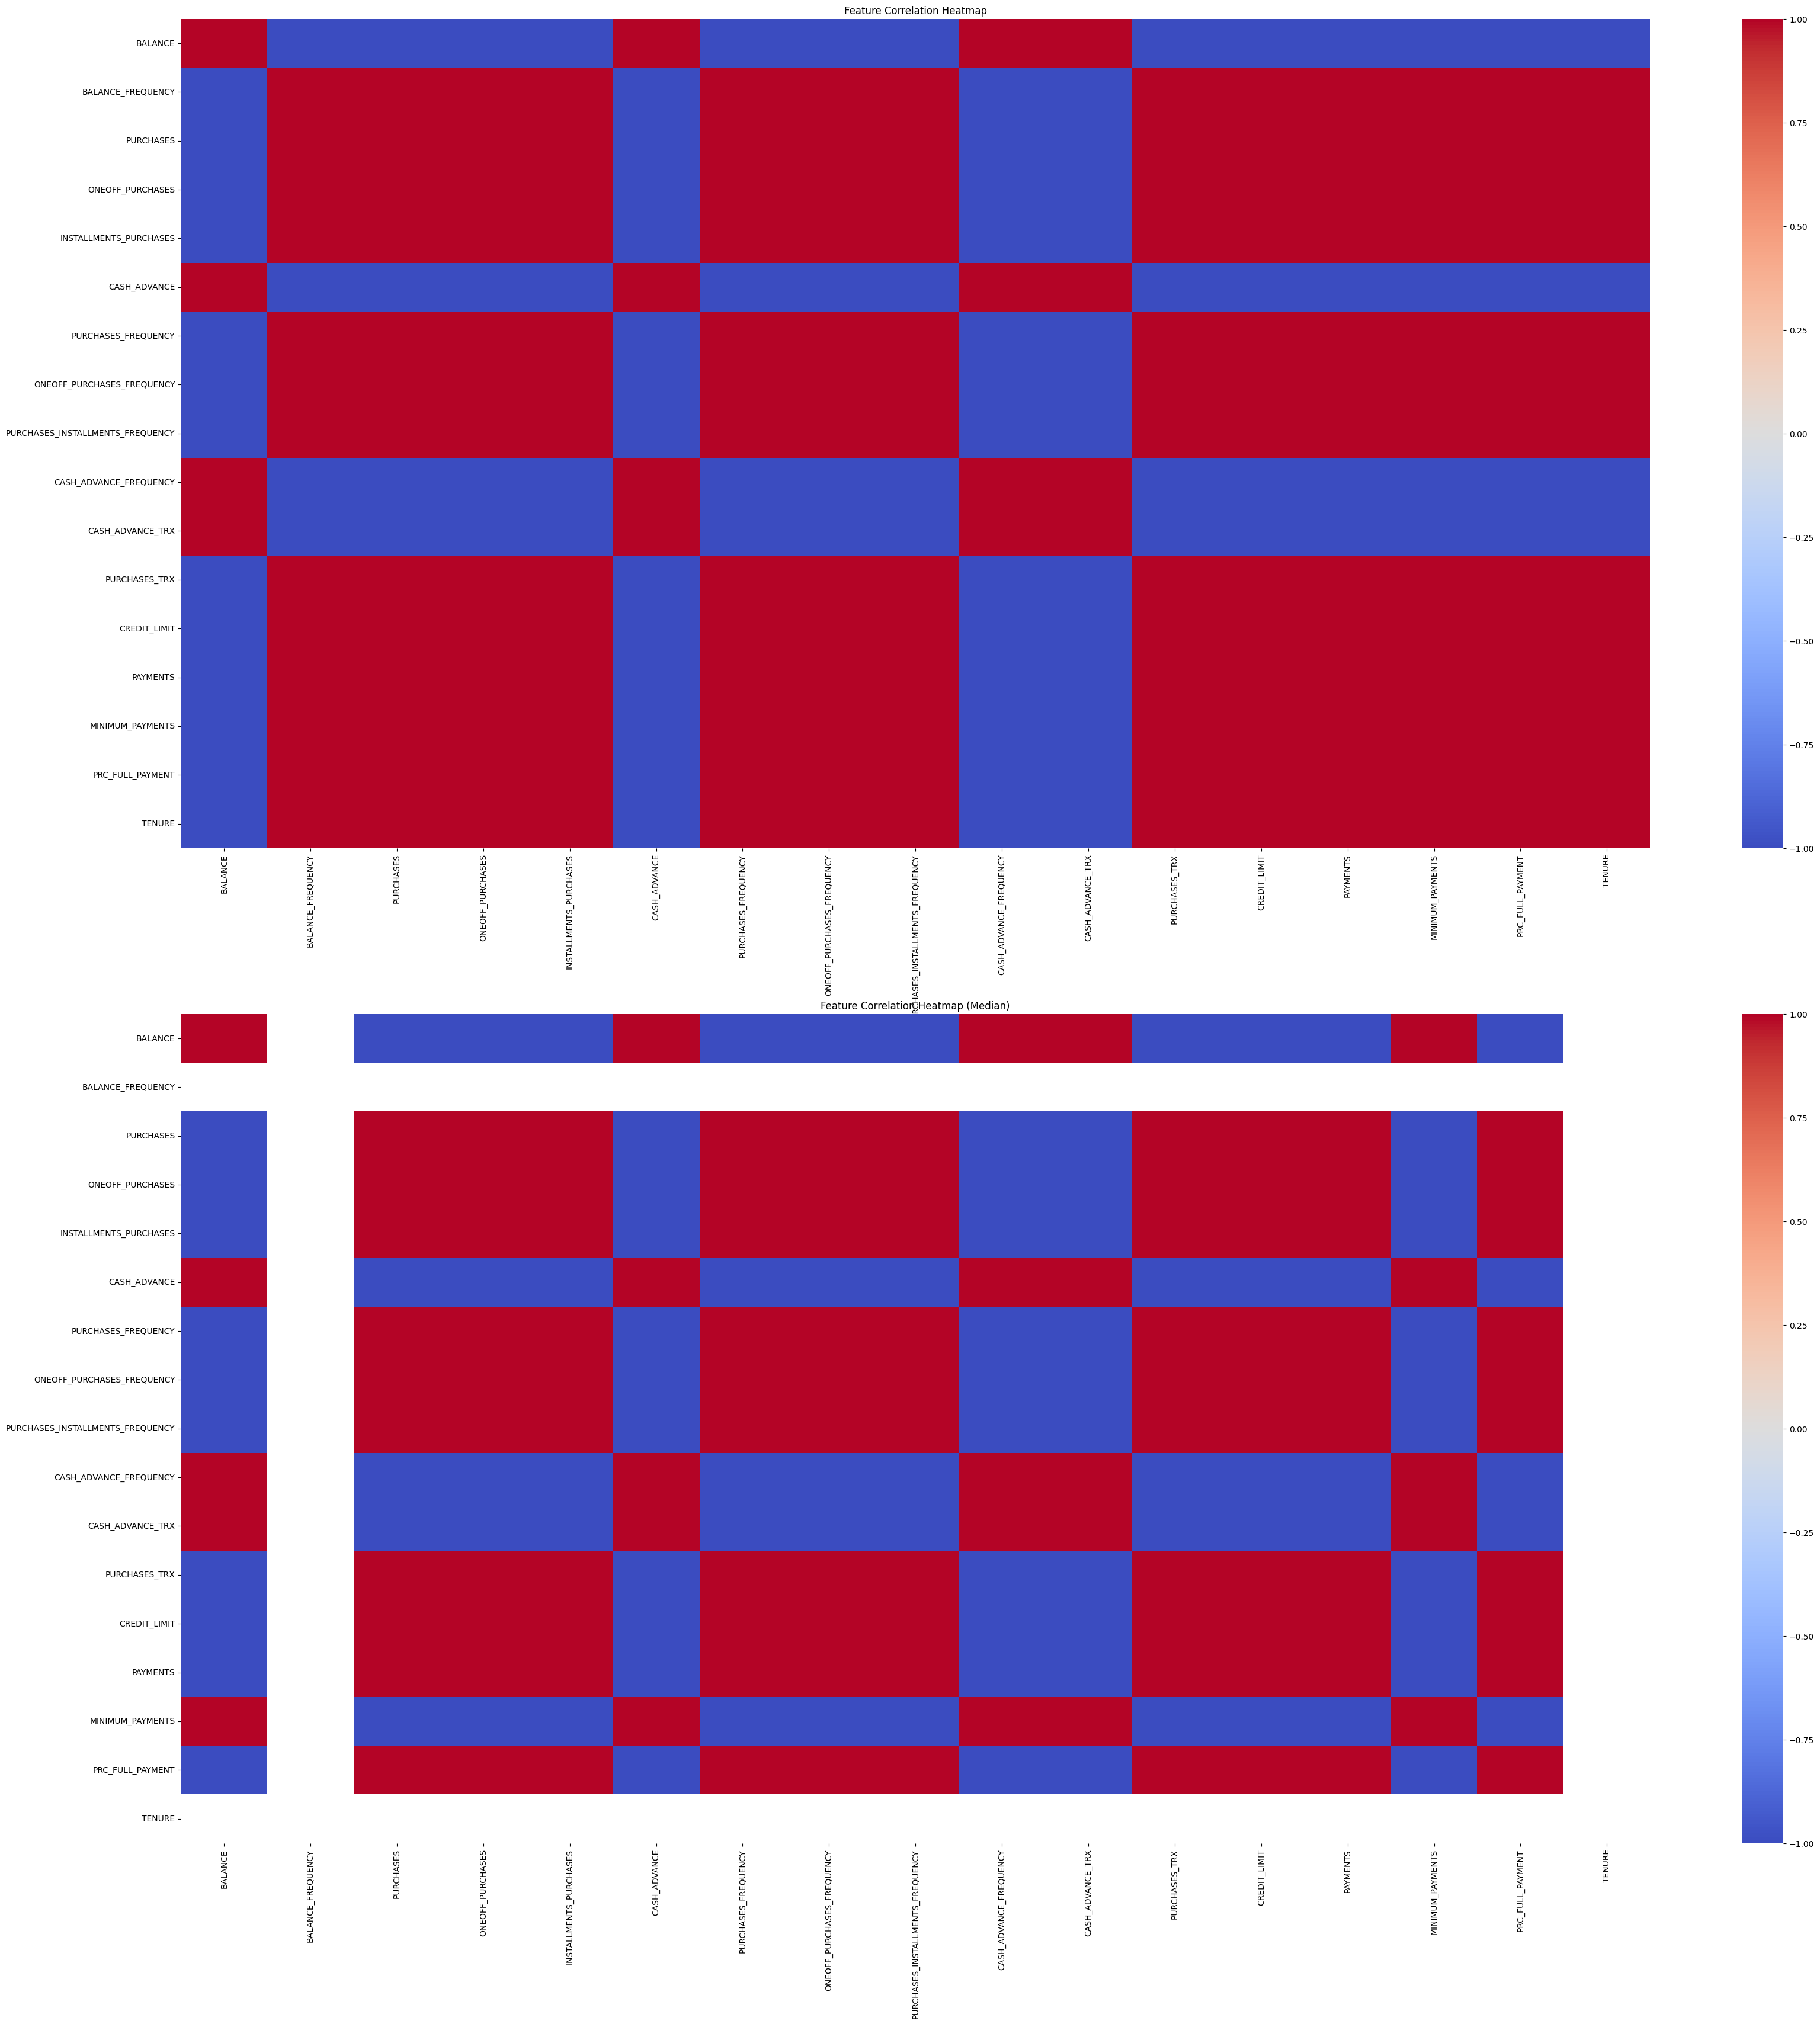

In [55]:
plt.figure(figsize=(40, 40))
plt.subplot(2, 1, 1)
sns.heatmap(clusters_mean.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

plt.subplot(2, 1, 2)
sns.heatmap(clusters_median.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap (Median)')
plt.show()

Поведение Сегмента 0:

Клиенты со средним балансом. Выполняют очень много транзакций, чаще всего берут в рассрочку.

Частые/лояльные клиенты

Поведение Сегмента 1:

Клиенты с высоким балансом. Выполняют не так много транзакций, очень осторожничают. Хотят быть уверены, потому что в основном платят сразу и закрывают одной транзакцией.

Не до конца вовлеченные клиенты

In [57]:
joblib.dump(k_means, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']